In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

BASE_DIR=Path(os.getcwd())
PROCESSED_DIR=BASE_DIR/"brd4_pipeline"/"data"/"processed"
FILTERED_DIR=BASE_DIR/"brd4_pipeline"/"data"/"filtered"
OUTPUTS_DIR=BASE_DIR/"brd4_pipeline"/"outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

df=pd.read_csv(FILTERED_DIR/"brd4_druglike.csv")

print(f"[INFO] Loaded {len(df):,} drug like BRD4 molecules")
print(f"[INFO] pIC50 range : {df['pIC50'].min():.2f} - {df['pIC50'].max():.2f}")
print(f"[INFO] Columns : {df.columns.tolist()}")

[INFO] Loaded 2,210 drug like BRD4 molecules
[INFO] pIC50 range : 3.59 - 10.92
[INFO] Columns : ['assay_type', 'canonical_smiles', 'data_validity_comment', 'molecule_chembl_id', 'pchembl_value', 'standard_type', 'standard_units', 'standard_value', 'type', 'units', 'value', 'standard_value_nM', 'pIC50', 'smiles_clean', 'is_pains', 'MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotB']


In [2]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

def get_murcko_scaffold(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None

    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)

        if scaffold is None or scaffold.GetNumAtoms() == 0:
            return None

        return Chem.MolToSmiles(scaffold, isomericSmiles=True)

    except Exception:
        return None


print("[INFO] Extracting Bemis-Murcko scaffolds...")
df['scaffold'] = df['smiles_clean'].apply(get_murcko_scaffold)

n_failed = df['scaffold'].isna().sum()
n_success = df['scaffold'].notna().sum()
n_unique  = df['scaffold'].nunique()

print(f"  Scaffolds extracted     : {n_success:,}")
print(f"  Failed extractions      : {n_failed:,}")
print(f"  Unique scaffolds found  : {n_unique:,}")
print(f"  Scaffold diversity      : {n_unique/n_success*100:.1f}% unique")

[INFO] Extracting Bemis-Murcko scaffolds...
  Scaffolds extracted     : 2,210
  Failed extractions      : 0
  Unique scaffolds found  : 837
  Scaffold diversity      : 37.9% unique


In [3]:
df_scaffolds=df.dropna(subset=['scaffold']).copy()

scaffold_stats=df_scaffolds.groupby('scaffold').agg(
    count = ('pIC50', 'count'),
    mean_pIC50 = ('pIC50','mean'),
    max_pIC50 = ('pIC50','max'),
    min_pIC50 = ('pIC50','min'),
    std_pIC50 = ('pIC50','std')).reset_index()

scaffold_stats=scaffold_stats.round(3)

scaffold_stats=scaffold_stats.sort_values('count',ascending=False)
scaffold_stats=scaffold_stats.reset_index(drop=True)

print(f"Total unique scaffolds : {len(scaffold_stats):,}")
print(f"\nTop 15 most frequent scaffolds:")
print(scaffold_stats.head(15).to_string(index=False))

Total unique scaffolds : 837

Top 15 most frequent scaffolds:
                                    scaffold  count  mean_pIC50  max_pIC50  min_pIC50  std_pIC50
   O=C(Nc1cnccc1C1CCCCC1)c1cccc(-c2ccccc2)n1     89       8.006      9.046      5.180      0.681
         O=C1NCCc2[nH]c(-c3cccc4nccnc34)cc21     78       8.216     10.000      6.000      0.894
 c1ccc(-c2ccc3cnc(Nc4cnccc4N4CCCCC4)n3n2)cc1     38       8.584     10.097      6.000      0.952
         O=C1NCCn2c1cc(-c1ccccc1)c2-c1ccccc1     36       7.415      8.523      6.759      0.456
              c1ccc2nc(-c3nnc4ccccn34)ccc2c1     33       6.436      7.770      5.000      0.670
    O=C(Nc1cnccc1N1CCCCC1)c1csc(-c2ccccc2)n1     31       7.675      8.699      5.823      0.755
         O=C(Nc1cnccc1N1CCCCC1)c1coc2cccnc12     30       7.280      8.000      5.699      0.565
   O=C1NCc2[nH]c(-c3cccc4c(=O)[nH]cnc34)cc21     27       9.434     10.921      8.301      0.720
     c1ccc(-c2cccc(CNc3cnccc3N3CCCCC3)n2)cc1     24       6.546  

In [5]:
privileged=scaffold_stats[
    (scaffold_stats['count'] >=5) &
    (scaffold_stats['mean_pIC50'] >=7.0) &
    (scaffold_stats['max_pIC50'] >=8.0)].copy()

privileged=privileged.sort_values('mean_pIC50', ascending=False)
privileged=privileged.reset_index(drop=True)

print(f"Privileged scaffolds identified : {len(privileged):,}")
print(f"\nTop 10 privileged scaffolds (by mean pIC50):")
print(privileged.head(10).to_string(index=False))

scaffold_file=PROCESSED_DIR/"brd4_scaffold_analysis.csv"
scaffold_stats.to_csv(scaffold_file, index=False)
print(f"\n[SAVED]  {scaffold_file}")

privileged_file=PROCESSED_DIR/"brd4_privileged_scaffolds.csv"
privileged.to_csv(privileged_file, index=False)
print(f"[SAVED] {privileged_file}")

Privileged scaffolds identified : 36

Top 10 privileged scaffolds (by mean pIC50):
                                                 scaffold  count  mean_pIC50  max_pIC50  min_pIC50  std_pIC50
          O=C1NC[C@@H]2CCCCNc3cnc4cccc(c4n3)-c3cc1c2[nH]3      5       9.664     10.301      9.398      0.377
                O=C1NCc2[nH]c(-c3cccc4c(=O)[nH]cnc34)cc21     27       9.434     10.921      8.301      0.720
              O=C1NCCc2[nH]c(-c3cccc4ncc(NC5CC5)nc34)cc21      6       9.401      9.790      8.699      0.369
               O=C1NCc2[nH]c(-c3cccc4ncc(NC5CC5)nc34)cc21     16       9.328     10.315      8.434      0.554
                 O=C1NC2(CC2)c2[nH]c(-c3cccc4nccnc34)cc21      5       9.137      9.652      8.866      0.330
c1ccc(-c2ccc3[nH]nc(-c4cncc(O[C@H]5CNCCC56CC6)n4)c3c2)cc1      7       8.973      9.398      8.367      0.335
                       O=C1NCc2[nH]c(-c3cccc4nccnc34)cc21     20       8.902     10.000      7.488      0.601
           O=C1NCCc2[nH]c(-c3cccc4ncc

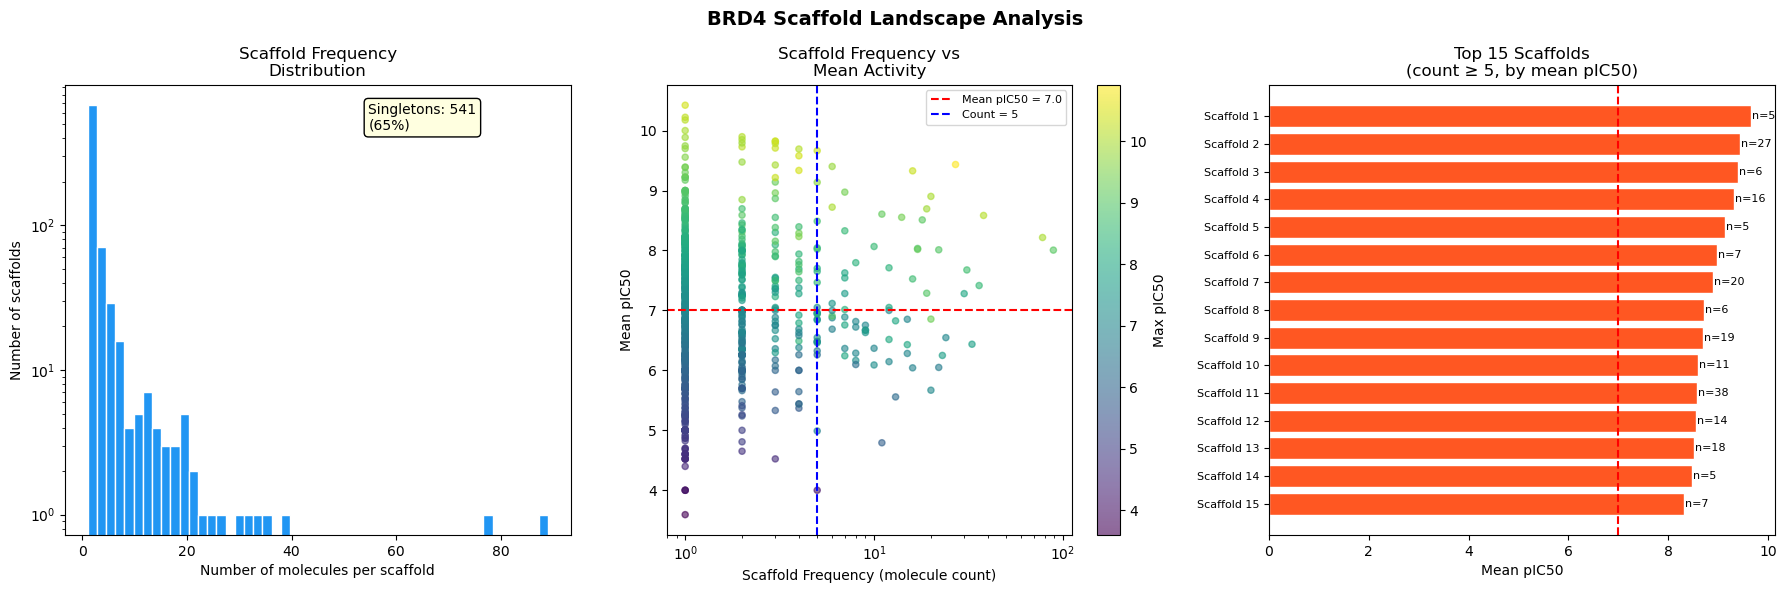

[SAVED] Scaffold landscape plot saved.


In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('BRD4 Scaffold Landscape Analysis',
             fontsize=14, fontweight='bold')

axes[0].hist(scaffold_stats['count'], bins=50,
             color='#2196F3', edgecolor='white')
axes[0].set_xlabel('Number of molecules per scaffold')
axes[0].set_ylabel('Number of scaffolds')
axes[0].set_title('Scaffold Frequency\nDistribution')
axes[0].set_yscale('log')

singleton_count = (scaffold_stats['count'] == 1).sum()
axes[0].text(0.6, 0.9,
             f'Singletons: {singleton_count:,}\n({singleton_count/len(scaffold_stats)*100:.0f}%)',
             transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow'))

sc = axes[1].scatter(
    scaffold_stats['count'],
    scaffold_stats['mean_pIC50'],
    c=scaffold_stats['max_pIC50'],
    cmap='viridis',
    alpha=0.6, s=20
)
plt.colorbar(sc, ax=axes[1], label='Max pIC50')

axes[1].axhline(y=7.0, color='red', linestyle='--',
                linewidth=1.5, label='Mean pIC50 = 7.0')
axes[1].axvline(x=5,   color='blue', linestyle='--',
                linewidth=1.5, label='Count = 5')

axes[1].set_xlabel('Scaffold Frequency (molecule count)')
axes[1].set_ylabel('Mean pIC50')
axes[1].set_title('Scaffold Frequency vs\nMean Activity')
axes[1].set_xscale('log')
axes[1].legend(fontsize=8)

top15_active = scaffold_stats[scaffold_stats['count'] >= 5]\
    .sort_values('mean_pIC50', ascending=False).head(15)

colors = ['#FF5722' if m >= 7.0 else '#90A4AE'
          for m in top15_active['mean_pIC50']]

bars = axes[2].barh(
    range(len(top15_active)),
    top15_active['mean_pIC50'],
    color=colors, edgecolor='white'
)

for i, (_, row) in enumerate(top15_active.iterrows()):
    axes[2].text(row['mean_pIC50'] + 0.02, i,
                 f"n={int(row['count'])}",
                 va='center', fontsize=8)

axes[2].axvline(x=7.0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_yticks(range(len(top15_active)))
axes[2].set_yticklabels([f"Scaffold {i+1}"
                          for i in range(len(top15_active))],
                          fontsize=8)
axes[2].invert_yaxis()
axes[2].set_xlabel('Mean pIC50')
axes[2].set_title('Top 15 Scaffolds\n(count ≥ 5, by mean pIC50)')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "module07_scaffold_landscape.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] Scaffold landscape plot saved.")

In [7]:
from rdkit.Chem import AllChem, Draw
from rdkit.Chem import rdRGroupDecomposition as rgd

if len(privileged) > 0:
    top_scaffold_smiles=privileged.iloc[0]['scaffold']
    top_scaffold_count=privileged.iloc[0]['count']
    top_scaffold_pic50=privileged.iloc[0]['mean_pIC50']
else:
    top_scaffold_smiles=scaffold_stats.iloc[0]['scaffold']
    top_scaffold_count=scaffold_stats.iloc[0]['count']
    top_scaffold_pic50=scaffold_stats.iloc[0]['mean_pIC50']

print(f"Top scaffold selected:")
print(f" SMILES : {top_scaffold_smiles}")
print(f" Frequency : {top_scaffold_count}")
print(f" Mean pIC50 : {top_scaffold_pic50}")

df_top=df_scaffolds[df_scaffolds['scaffold']==top_scaffold_smiles].copy().reset_index(drop=True)

print(f"\nMolecules sharing this scaffold : {len(df_top):,}")
print(f"pIC50 range : {df_top['pIC50'].min():.2f}- {df_top['pIC50'].max():.2f}")


mols=[]
valid_idx=[]
for i, smi in enumerate(df_top['smiles_clean']):
    mol=Chem.MolFromSmiles(str(smi))
    if mol is None:
        mols.append(mol)
        valid_idx.append(i)

print(f"\n[INFO] Running R-Group decomposition om {len(mols)} molecules...")

try:
    rgroups, unmatched = rgd.RGroupDecompose(
        [core_mol], mols,
        asSmiles=True,
        asRows=True)
    df_rgroups=pd.DataFrame(rgroups)
    df_rgroups['pIC50']=df_top.iloc[valid_idx]['pIC50'].values

    print(f"[DONE] R-Group decomposition complete.")
    print(f" Molecules decomposed : {len(df_groups):,}")
    print(f" Unmatched  : {len(unmatched):,}")
    print(f" R-group columns : {[c for c in df_rgroups.columns if c.startswith('R')]}")
    print(f"\nFirst 5 Rows :")
    print(df_rgroups.head())

except Exception as e:
    print(f"[WARNINGS] R-group decomposition encountered: {e}")
    print("[INFO] Proceeding with scaffold activity analysis only.")
    df_rgroups=pd.DataFrame()

Top scaffold selected:
 SMILES : O=C1NC[C@@H]2CCCCNc3cnc4cccc(c4n3)-c3cc1c2[nH]3
 Frequency : 5
 Mean pIC50 : 9.664

Molecules sharing this scaffold : 5
pIC50 range : 9.40- 10.30

[INFO] Running R-Group decomposition om 0 molecules...
[WARNINGS] R-group decomposition encountered: name 'core_mol' is not defined
[INFO] Proceeding with scaffold activity analysis only.


In [10]:
if len(df_rgroups)>0:
    r_cols=[c for c in df_rgroups.columns if c.startswith('R')]

    print("="*55)
    print(" R-GROUP ACTIVITY ANALYSIS")
    print(f" Core scaffold : {top_scaffold_smiles[:50]}...")
    print("="*55)

    for r_col in r_cols:
        print(f"\n----{r_col} substituent activity----")

        r_activity=df_rgroups.groupby(r_col)['pIC50'].agg(count='count',mean_pIC50='mean',max_pIC50='max').reset_index()

        r_activity=r_activity[r_activity['count']>=2]
        r_activity=r_activity.sort_values('mean_pIC50',ascending=False)
        r_activity=r_activity.round(3)

        print(r_activity.head(10).to_string(index=False))

    rgroup_file=PROCESSED_DIR/"brd4_rgroup_analysis.csv"
    df_rgroups.to_csv(rgroup_file, index=False)
    print(f"\n[SAVED] {rgroup_file}")
else:
    print("[INFO] R-group decomposition not available.")
    print("[INFO] Scaffold activity analysis saved instead.")

[INFO] R-group decomposition not available.
[INFO] Scaffold activity analysis saved instead.


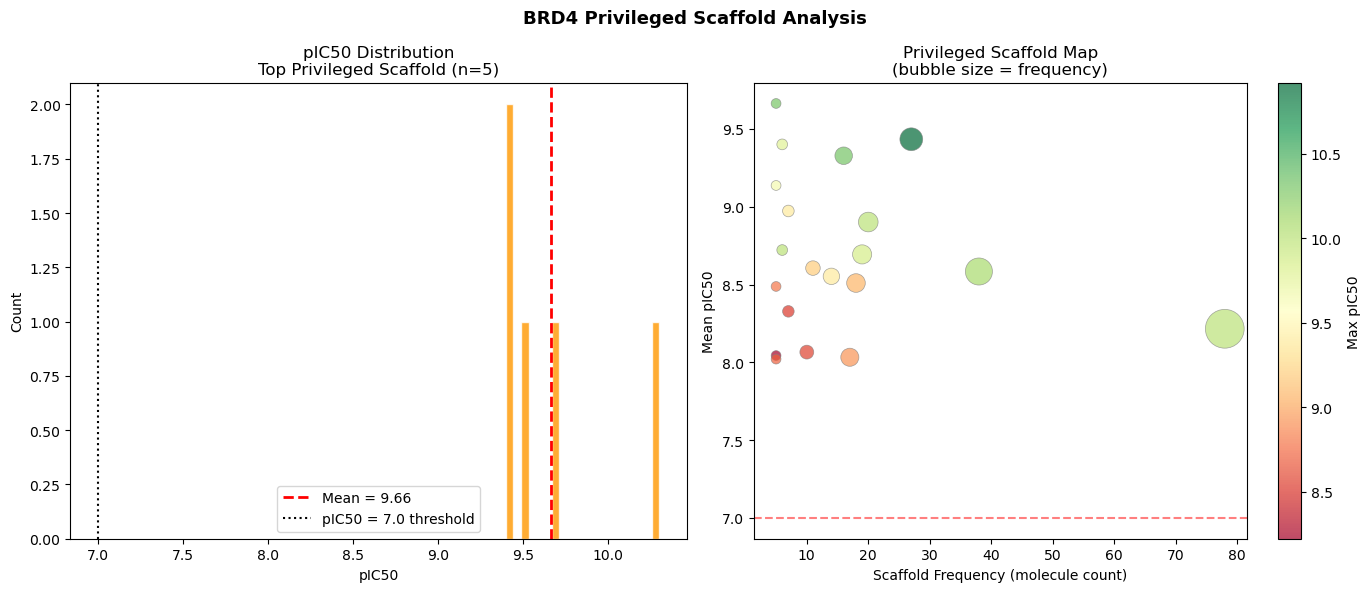

[SAVED] Privileged scaffold plot saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('BRD4 Privileged Scaffold Analysis',
             fontsize=13, fontweight='bold')

if len(df_top) > 0:
    axes[0].hist(df_top['pIC50'], bins=20,
                 color='#FF9800', edgecolor='white', alpha=0.8)
    axes[0].axvline(x=df_top['pIC50'].mean(),
                    color='red', linestyle='--', linewidth=2,
                    label=f"Mean = {df_top['pIC50'].mean():.2f}")
    axes[0].axvline(x=7.0, color='black', linestyle=':',
                    linewidth=1.5, label='pIC50 = 7.0 threshold')
    axes[0].set_xlabel('pIC50')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'pIC50 Distribution\nTop Privileged Scaffold (n={len(df_top)})')
    axes[0].legend()

if len(privileged) > 0:
    plot_data = privileged.head(20)

    scatter = axes[1].scatter(
        plot_data['count'],
        plot_data['mean_pIC50'],
        s=plot_data['count'] * 10,  # Bubble size = frequency
        c=plot_data['max_pIC50'],
        cmap='RdYlGn',
        alpha=0.7,
        edgecolors='grey',
        linewidth=0.5
    )
    plt.colorbar(scatter, ax=axes[1], label='Max pIC50')

    axes[1].set_xlabel('Scaffold Frequency (molecule count)')
    axes[1].set_ylabel('Mean pIC50')
    axes[1].set_title('Privileged Scaffold Map\n(bubble size = frequency)')
    axes[1].axhline(y=7.0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "module07_privileged_scaffolds.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] Privileged scaffold plot saved.")

In [13]:
print("=" * 55)
print("  MODULE 7 — PIPELINE AUDIT REPORT")
print("  Target: BRD4 (CHEMBL4523)")
print("=" * 55)
print(f"  Molecules analyzed      : {len(df_scaffolds):,}")
print(f"  Unique scaffolds found  : {scaffold_stats['scaffold'].nunique():,}")
print(f"  Singleton scaffolds     : {(scaffold_stats['count']==1).sum():,}")
print(f"  Privileged scaffolds    : {len(privileged):,}")
print()
print(f"  Top privileged scaffold:")
if len(privileged) > 0:
    print(f"    Frequency   : {int(privileged.iloc[0]['count'])} molecules")
    print(f"    Mean pIC50  : {privileged.iloc[0]['mean_pIC50']:.2f}")
    print(f"    Max pIC50   : {privileged.iloc[0]['max_pIC50']:.2f}")
    print(f"    SMILES      : {privileged.iloc[0]['scaffold'][:50]}...")
print()
print(f"  R-group decomposition   : {'Complete' if len(df_rgroups)>0 else 'Skipped'}")
print()
print("  Files saved:")
print("  processed/  brd4_scaffold_analysis.csv")
print("  processed/  brd4_privileged_scaffolds.csv")
if len(df_rgroups) > 0:
    print("  processed/  brd4_rgroup_analysis.csv")
print("  outputs/    module07_scaffold_landscape.png")
print("  outputs/    module07_privileged_scaffolds.png")
print("=" * 55)
print("  Module 7 complete.")
print("=" * 55)

  MODULE 7 — PIPELINE AUDIT REPORT
  Target: BRD4 (CHEMBL4523)
  Molecules analyzed      : 2,210
  Unique scaffolds found  : 837
  Singleton scaffolds     : 541
  Privileged scaffolds    : 36

  Top privileged scaffold:
    Frequency   : 5 molecules
    Mean pIC50  : 9.66
    Max pIC50   : 10.30
    SMILES      : O=C1NC[C@@H]2CCCCNc3cnc4cccc(c4n3)-c3cc1c2[nH]3...

  R-group decomposition   : Skipped

  Files saved:
  processed/  brd4_scaffold_analysis.csv
  processed/  brd4_privileged_scaffolds.csv
  outputs/    module07_scaffold_landscape.png
  outputs/    module07_privileged_scaffolds.png
  Module 7 complete.
